### 1) Required installs

In [1]:
!pip -q install groq scikit-learn pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.8 MB/s eta 0:00:00


### 2) Imports

In [2]:
import os
import re
import json
import time
import shutil
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from groq import Groq

PROJECT_DIR = Path("/content/maintainers-copilot")
SPLITS_DIR = PROJECT_DIR / "data" / "splits"
REPORTS_DIR = PROJECT_DIR / "data" / "reports"

SPLITS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["bug", "docs", "feature", "question"]

print("Folders ready.")

Folders ready.


### 3) Checking Groq API key

In [3]:
try:
    from google.colab import userdata
    groq_key = userdata.get("GROQ_API_KEY")
except Exception:
    groq_key = None

if not groq_key:
    import getpass
    groq_key = getpass.getpass("Paste your GROQ_API_KEY: ")

os.environ["GROQ_API_KEY"] = groq_key

client = Groq(api_key=os.environ["GROQ_API_KEY"])

print("Groq client ready.")

Groq client ready.


### 4) Checking test split file is uploaded

In [4]:
from google.colab import files

print("Upload test.jsonl from your local data/splits folder.")
uploaded = files.upload()

for filename in uploaded.keys():
    target = SPLITS_DIR / filename
    shutil.move(filename, target)
    print("Saved:", target)

Upload test.jsonl from your local data/splits folder.


Saving test.jsonl to test.jsonl
Saved: /content/maintainers-copilot/data/splits/test.jsonl


### 5) Load dataset into a dataframe

In [5]:
def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

test_df = load_jsonl(SPLITS_DIR / "test.jsonl")

print("Test shape:", test_df.shape)
print("\nColumns:")
print(test_df.columns.tolist())

print("\nLabel distribution:")
print(test_df["mapped_label"].value_counts())

Test shape: (100, 11)

Columns:
['external_id', 'repo', 'number', 'title', 'body', 'state', 'labels', 'mapped_label', 'created_at', 'closed_at', 'url']

Label distribution:
mapped_label
bug         55
question    25
docs        15
feature      5
Name: count, dtype: int64


### 6) Build issue text

Combines issue title and body into one input for the LLM.

In [6]:
def clean_text(value):
    if value is None:
        return ""
    if isinstance(value, float) and pd.isna(value):
        return ""
    return str(value)

def build_issue_text(row, max_chars=6000):
    title = clean_text(row.get("title", ""))
    body = clean_text(row.get("body", ""))

    text = f"Title:\n{title}\n\nBody:\n{body}"
    return text[:max_chars]

test_df["text"] = test_df.apply(build_issue_text, axis=1)

print(test_df[["text", "mapped_label"]].head(2).to_string())

### 7) Prompt

In [7]:
SYSTEM_PROMPT = """
You are a GitHub issue triage classifier.

Classify each issue into exactly one of these labels:

bug:
The issue reports broken behavior, an error, a regression, unexpected behavior, or something not working.

docs:
The issue asks for documentation improvements, missing docs, confusing docs, examples, tutorials, or clarification in docs.

feature:
The issue requests a new capability, enhancement, improvement, API addition, or behavior change.

question:
The issue asks for help, support, usage guidance, troubleshooting, or explanation.

Return only valid JSON:
{"label": "bug|docs|feature|question"}
"""

def make_user_prompt(issue_text: str) -> str:
    return f"""
Classify this GitHub issue.

{issue_text}

Return only JSON.
"""

### 8) Define response parser

Extracts a safe label even if the model adds extra text.

In [8]:
def parse_label(raw_text: str) -> str:
    text = raw_text.strip()

    try:
        data = json.loads(text)
        label = str(data.get("label", "")).strip().lower()
        if label in LABELS:
            return label
    except Exception:
        pass

    match = re.search(r'"label"\s*:\s*"([^"]+)"', text, re.IGNORECASE)
    if match:
        label = match.group(1).strip().lower()
        if label in LABELS:
            return label

    lowered = text.lower()
    for label in LABELS:
        if re.search(rf"\b{label}\b", lowered):
            return label

    return "parse_error"

### 9) Define Groq classification function

Sends one issue to Groq and records prediction, latency, and token usage.

In [9]:
GROQ_MODEL = "llama-3.3-70b-versatile"

def classify_with_groq(issue_text: str, max_retries=3):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT.strip()},
        {"role": "user", "content": make_user_prompt(issue_text).strip()},
    ]

    last_error = None

    for attempt in range(max_retries):
        try:
            start = time.time()

            response = client.chat.completions.create(
                model=GROQ_MODEL,
                messages=messages,
                temperature=0,
                max_tokens=30,
            )

            latency_ms = round((time.time() - start) * 1000, 2)
            raw = response.choices[0].message.content
            pred_label = parse_label(raw)

            usage = getattr(response, "usage", None)
            prompt_tokens = getattr(usage, "prompt_tokens", None) if usage else None
            completion_tokens = getattr(usage, "completion_tokens", None) if usage else None
            total_tokens = getattr(usage, "total_tokens", None) if usage else None

            return {
                "pred_label": pred_label,
                "raw_response": raw,
                "latency_ms": latency_ms,
                "prompt_tokens": prompt_tokens,
                "completion_tokens": completion_tokens,
                "total_tokens": total_tokens,
                "error": None,
            }

        except Exception as e:
            last_error = str(e)
            sleep_seconds = 2 ** attempt
            time.sleep(sleep_seconds)

    return {
        "pred_label": "api_error",
        "raw_response": "",
        "latency_ms": None,
        "prompt_tokens": None,
        "completion_tokens": None,
        "total_tokens": None,
        "error": last_error,
    }

### 10) Test on 3 examples first

Checks that the API and parser work before spending time on the full test set.

In [10]:
sample_df = test_df.sample(min(3, len(test_df)), random_state=42)

for _, row in sample_df.iterrows():
    result = classify_with_groq(row["text"])
    print("=" * 80)
    print("TRUE:", row["mapped_label"])
    print("PRED:", result["pred_label"])
    print("RAW:", result["raw_response"])
    print("LATENCY MS:", result["latency_ms"])
    print("ERROR:", result["error"])

TRUE: feature
PRED: feature
RAW: {"label": "feature"}
LATENCY MS: 515.6
ERROR: None
TRUE: docs
PRED: bug
RAW: {"label": "bug"}
LATENCY MS: 195.7
ERROR: None
TRUE: bug
PRED: bug
RAW: {"label": "bug"}
LATENCY MS: 312.69
ERROR: None


### 11) Run LLM baseline on full test split

In [11]:
prediction_rows = []

for i, row in tqdm(test_df.reset_index(drop=True).iterrows(), total=len(test_df)):
    result = classify_with_groq(row["text"])

    prediction_rows.append({
        "id": row.get("id"),
        "url": row.get("url"),
        "title": row.get("title"),
        "true_label": row.get("mapped_label"),
        "pred_label": result["pred_label"],
        "raw_response": result["raw_response"],
        "latency_ms": result["latency_ms"],
        "prompt_tokens": result["prompt_tokens"],
        "completion_tokens": result["completion_tokens"],
        "total_tokens": result["total_tokens"],
        "error": result["error"],
        "model": GROQ_MODEL,
    })

    # Small delay to reduce rate-limit risk.
    time.sleep(0.2)

predictions_path = REPORTS_DIR / "llm_baseline_predictions.jsonl"

with predictions_path.open("w", encoding="utf-8") as f:
    for item in prediction_rows:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("Saved:", predictions_path)

  0%|          | 0/100 [00:00<?, ?it/s]

Saved: /content/maintainers-copilot/data/reports/llm_baseline_predictions.jsonl


### 12) Load predictions and check errors

Checks if any API or parsing failures happened.

In [12]:
pred_df = pd.DataFrame(prediction_rows)

print("Prediction counts:")
print(pred_df["pred_label"].value_counts(dropna=False))

print("\nErrors:")
print(pred_df["error"].value_counts(dropna=False).head(10))

bad_df = pred_df[~pred_df["pred_label"].isin(LABELS)]

print("\nInvalid predictions:", len(bad_df))

if len(bad_df) > 0:
    display(bad_df[["title", "true_label", "pred_label", "raw_response", "error"]].head(10))

Prediction counts:
pred_label
bug         71
feature     13
question     9
docs         7
Name: count, dtype: int64

Errors:
error
None    100
Name: count, dtype: int64

Invalid predictions: 0


### 13) Evaluate valid predictions

Computes accuracy, macro-F1, weighted-F1, and per-class F1.

In [13]:
eval_df = pred_df[pred_df["pred_label"].isin(LABELS)].copy()

if len(eval_df) == 0:
    raise ValueError("No valid predictions. Check Groq responses and parser.")

y_true = eval_df["true_label"].tolist()
y_pred = eval_df["pred_label"].tolist()

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, labels=LABELS, average="weighted", zero_division=0)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=LABELS,
    target_names=LABELS,
    output_dict=True,
    zero_division=0,
)

report_text = classification_report(
    y_true,
    y_pred,
    labels=LABELS,
    target_names=LABELS,
    zero_division=0,
)

print("Accuracy:", accuracy)
print("Macro-F1:", macro_f1)
print("Weighted-F1:", weighted_f1)
print()
print(report_text)

Accuracy: 0.69
Macro-F1: 0.556765130294542
Weighted-F1: 0.6609498344792462

              precision    recall  f1-score   support

         bug       0.73      0.95      0.83        55
        docs       0.86      0.40      0.55        15
     feature       0.31      0.80      0.44         5
    question       0.78      0.28      0.41        25

    accuracy                           0.69       100
   macro avg       0.67      0.61      0.56       100
weighted avg       0.74      0.69      0.66       100



### 14) Confusion matrix

,pred_bug,pred_docs,pred_feature,pred_question
true_bug,52,0,3,0
true_docs,3,6,5,1
true_feature,0,0,4,1
true_question,16,1,1,7


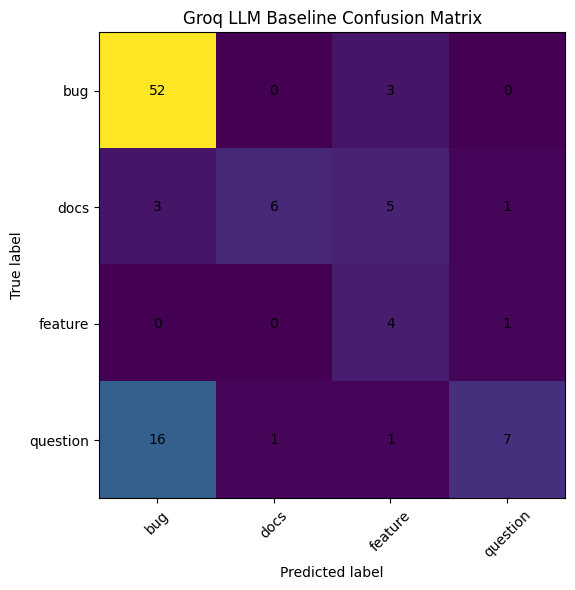

Saved: /content/maintainers-copilot/data/reports/llm_baseline_confusion_matrix.png


In [14]:
cm = confusion_matrix(y_true, y_pred, labels=LABELS)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{label}" for label in LABELS],
    columns=[f"pred_{label}" for label in LABELS],
)

display(cm_df)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Groq LLM Baseline Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(len(LABELS)), LABELS, rotation=45)
plt.yticks(range(len(LABELS)), LABELS)

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

cm_path = REPORTS_DIR / "llm_baseline_confusion_matrix.png"
plt.savefig(cm_path, dpi=160)

plt.show()

print("Saved:", cm_path)

### 15) Latency and token summary

Calculates average latency and token usage, needed for your deployment decision.

In [15]:
latencies = pd.to_numeric(pred_df["latency_ms"], errors="coerce")
tokens = pd.to_numeric(pred_df["total_tokens"], errors="coerce")

latency_summary = {
    "mean_latency_ms": float(latencies.mean()),
    "median_latency_ms": float(latencies.median()),
    "p95_latency_ms": float(latencies.quantile(0.95)),
    "min_latency_ms": float(latencies.min()),
    "max_latency_ms": float(latencies.max()),
}

token_summary = {
    "mean_total_tokens": float(tokens.mean()),
    "median_total_tokens": float(tokens.median()),
    "total_tokens": int(tokens.fillna(0).sum()),
}

print("Latency summary:")
print(json.dumps(latency_summary, indent=2))

print("\nToken summary:")
print(json.dumps(token_summary, indent=2))

Latency summary:
{
  "mean_latency_ms": 2271.7614,
  "median_latency_ms": 1334.795,
  "p95_latency_ms": 8741.985999999997,
  "min_latency_ms": 123.63,
  "max_latency_ms": 10770.43
}

Token summary:
{
  "mean_total_tokens": 605.91,
  "median_total_tokens": 357.5,
  "total_tokens": 60591
}


### 16) Estimate cost placeholder

Stores the token counts.

In [16]:
cost_summary = {
    "provider": "Groq",
    "model": GROQ_MODEL,
    "note": "Exact cost depends on current Groq pricing and account plan. Token counts are stored for cost calculation.",
    "total_prompt_tokens": int(pd.to_numeric(pred_df["prompt_tokens"], errors="coerce").fillna(0).sum()),
    "total_completion_tokens": int(pd.to_numeric(pred_df["completion_tokens"], errors="coerce").fillna(0).sum()),
    "total_tokens": int(pd.to_numeric(pred_df["total_tokens"], errors="coerce").fillna(0).sum()),
}

print(json.dumps(cost_summary, indent=2))

{
  "provider": "Groq",
  "model": "llama-3.3-70b-versatile",
  "note": "Exact cost depends on current Groq pricing and account plan. Token counts are stored for cost calculation.",
  "total_prompt_tokens": 59891,
  "total_completion_tokens": 700,
  "total_tokens": 60591
}


### 17) Save metrics report

In [17]:
metrics = {
    "provider": "Groq",
    "model": GROQ_MODEL,
    "task": "issue_classification_llm_baseline",
    "labels": LABELS,
    "num_test_examples": int(len(test_df)),
    "num_valid_predictions": int(len(eval_df)),
    "num_invalid_predictions": int(len(pred_df) - len(eval_df)),
    "accuracy": float(accuracy),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "classification_report": report_dict,
    "confusion_matrix": cm_df.to_dict(),
    "latency": latency_summary,
    "tokens": token_summary,
    "cost": cost_summary,
}

metrics_json_path = REPORTS_DIR / "llm_baseline_metrics.json"
metrics_txt_path = REPORTS_DIR / "llm_baseline_classification_report.txt"

with metrics_json_path.open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

with metrics_txt_path.open("w", encoding="utf-8") as f:
    f.write(report_text)

print("Saved:", metrics_json_path)
print("Saved:", metrics_txt_path)

Saved: /content/maintainers-copilot/data/reports/llm_baseline_metrics.json
Saved: /content/maintainers-copilot/data/reports/llm_baseline_classification_report.txt


### 18) Comparison draft

In [18]:
comparison_md = f"""
# LLM Baseline — Groq

Provider: Groq

Model: {GROQ_MODEL}

Dataset: kubernetes/kubernetes issue test split

Labels:

- bug
- docs
- feature
- question

## Metrics

Accuracy: {accuracy:.4f}

Macro-F1: {macro_f1:.4f}

Weighted-F1: {weighted_f1:.4f}

## Latency

Mean latency: {latency_summary["mean_latency_ms"]:.2f} ms

Median latency: {latency_summary["median_latency_ms"]:.2f} ms

P95 latency: {latency_summary["p95_latency_ms"]:.2f} ms

## Token usage

Total tokens: {token_summary["total_tokens"]}

Mean total tokens per request: {token_summary["mean_total_tokens"]:.2f}

## Notes

The LLM baseline was evaluated on the same test split as the fine-tuned transformer.

The LLM requires no training but depends on an external provider, has variable latency, and has per-request cost.

The fine-tuned transformer is expected to be cheaper and easier to run locally through the model server.
"""

comparison_path = REPORTS_DIR / "llm_baseline_decisions_draft.md"

with comparison_path.open("w", encoding="utf-8") as f:
    f.write(comparison_md)

print("Saved:", comparison_path)
print(comparison_md)

Saved: /content/maintainers-copilot/data/reports/llm_baseline_decisions_draft.md

# LLM Baseline — Groq

Provider: Groq

Model: llama-3.3-70b-versatile

Dataset: kubernetes/kubernetes issue test split

Labels:

- bug
- docs
- feature
- question

## Metrics

Accuracy: 0.6900

Macro-F1: 0.5568

Weighted-F1: 0.6609

## Latency

Mean latency: 2271.76 ms

Median latency: 1334.80 ms

P95 latency: 8741.99 ms

## Token usage

Total tokens: 60591

Mean total tokens per request: 605.91

## Notes

The LLM baseline was evaluated on the same test split as the fine-tuned transformer.

The LLM requires no training but depends on an external provider, has variable latency, and has per-request cost.

The fine-tuned transformer is expected to be cheaper and easier to run locally through the model server.



### 19) Zip outputs

In [19]:
ARTIFACT_ZIP = "/content/day2_llm_baseline_artifacts.zip"

if os.path.exists(ARTIFACT_ZIP):
    os.remove(ARTIFACT_ZIP)

shutil.make_archive(
    base_name=ARTIFACT_ZIP.replace(".zip", ""),
    format="zip",
    root_dir=PROJECT_DIR,
    base_dir="data/reports",
)

print("Created:", ARTIFACT_ZIP)

Created: /content/day2_llm_baseline_artifacts.zip


### 20) Downloading zipped file

In [20]:
from google.colab import files

files.download(ARTIFACT_ZIP)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>